# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [6]:
# Verificar tipos de dados
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
# Verificar valores nulos
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


In [9]:
# Estatísticas descritivas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [10]:
# Contagem da variável target
df['quality'].value_counts().sort_index()

,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


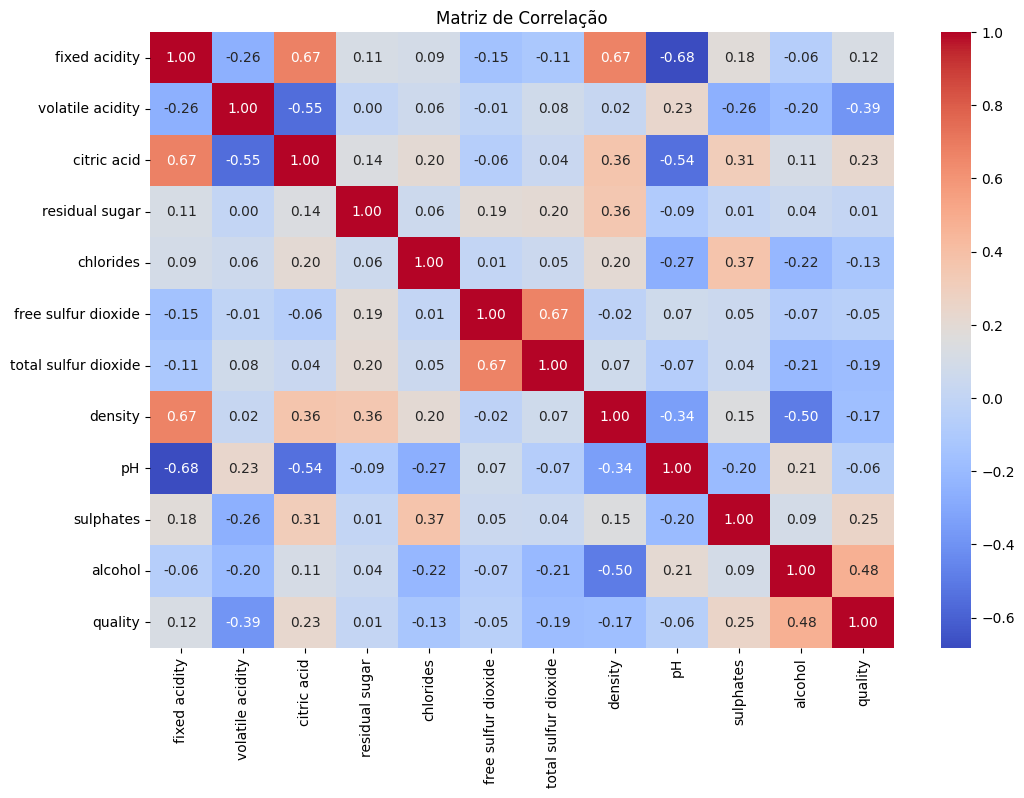

In [11]:
# Matriz de correlação
corr = df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Matriz de Correlação')

plt.show()

In [12]:
df_corr = df[[
    'alcohol',
    'volatile acidity',
    'sulphates',
    'citric acid',
    'total sulfur dioxide',
    'density',
    'quality'
]]

df_corr.head()

,alcohol,volatile acidity,sulphates,citric acid,total sulfur dioxide,density,quality
0,9.4,0.70,0.56,0.00,34.0,0.9978,5
1,9.8,0.88,0.68,0.00,67.0,0.9968,5
2,9.8,0.76,0.65,0.04,54.0,0.9970,5
3,9.8,0.28,0.58,0.56,60.0,0.9980,6
4,9.4,0.70,0.56,0.00,34.0,0.9978,5


# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


In [15]:
# Separando Features (x) e Target (y)

x = df_corr.drop('quality', axis=1)

y = df_corr['quality']

# Verificando dimensões
print("Shape de x:", x.shape)
print("Shape de y:", y.shape)

Shape de x: (1599, 6)
Shape de y: (1599,)


In [16]:
from sklearn.model_selection import train_test_split

# Divisão treino e teste

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Verificando tamanhos

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (1279, 6)
x_test: (320, 6)
y_train: (1279,)
y_test: (320,)


# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Inicializando o modelo

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Treinando o modelo

modelo_rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [18]:
# Fazendo previsões com os dados de teste

y_pred = modelo_rf.predict(x_test)

# Visualizando algumas previsões

y_pred[:10]

array([5, 5, 5, 5, 6, 5, 5, 5, 6, 6])

# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


# Relatório completo

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


# Matriz de confusão

cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de Confusão:\n")

print(cm)

Accuracy: 0.640625

Classification Report:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.68      0.78      0.73       130
           6       0.61      0.63      0.62       132
           7       0.61      0.48      0.53        42
           8       0.00      0.00      0.00         5

    accuracy                           0.64       320
   macro avg       0.32      0.31      0.31       320
weighted avg       0.61      0.64      0.62       320


Matriz de Confusão:

[[  0   0   0   1   0   0]
 [  0   0   6   4   0   0]
 [  0   0 102  27   1   0]
 [  0   0  41  83   8   0]
 [  0   0   0  21  20   1]
 [  0   0   0   1   4   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# INSIGHTS
Foi realizada a avaliação do modelo utilizando métricas como Accuracy, Precision, Recall e F1-score, além da matriz de confusão. O modelo apresentou Accuracy de 0.640625, indicando que cerca de 64% das previsões foram corretas, o que representa um desempenho moderado. Observando o classification report, nota-se que as classes 5 e 6 tiveram melhor desempenho (F1-score de 0.73 e 0.62, respectivamente), enquanto a classe 7 apresentou desempenho moderado (0.53). Já as classes 3, 4 e 8 apresentaram valores iguais a zero, indicando dificuldade do modelo em prever essas categorias. A matriz de confusão mostrou que a maioria dos erros ocorreu entre as classes 5 e 6, que possuem características semelhantes.

---



# DIFICULDADES
O modelo teve dificuldade para prever as classes 3, 4 e 8, e isso está relacionado ao desbalanceamento dos dados, pois essas classes possuem poucos registros no conjunto de teste (classe 3: 1 registro, classe 4: 10 registros e classe 8: 5 registros). Com poucas amostras, o modelo não consegue aprender adequadamente seus padrões, resultando em pior desempenho nas classes minoritárias e melhor desempenho nas classes mais frequentes, como 5 e 6.

# 6 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definindo o grid de parâmetros

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [21]:
# Criando modelo base

rf = RandomForestClassifier(random_state=42)

# Random Search

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,  # quantidade de combinações testadas
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Treinando

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, verbose=2)

In [22]:
print("Melhores parâmetros encontrados:")
print(random_search.best_params_)

Melhores parâmetros encontrados:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}


In [23]:
# Melhor modelo

best_model = random_search.best_estimator_

# Previsões

y_pred_rs = best_model.predict(x_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

# Accuracy

accuracy_rs = accuracy_score(y_test, y_pred_rs)

print("Nova Accuracy:", accuracy_rs)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rs))

Nova Accuracy: 0.659375

Classification Report:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.70      0.78      0.74       130
           6       0.62      0.66      0.64       132
           7       0.65      0.52      0.58        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


O desempenho do modelo melhorou após a aplicação do Random Search. A accuracy aumentou de 0.640625 para 0.659375, indicando que o ajuste dos hiperparâmetros tornou o modelo mais eficiente. Também houve pequenas melhorias nos valores de precision, recall e F1-score para as classes 5, 6 e 7. Isso mostra que os novos parâmetros encontrados permitiram ao modelo aprender melhor os padrões dos dados. No entanto, o modelo ainda apresentou dificuldade em prever classes minoritárias, devido ao desbalanceamento dos dados.

# 7 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

**RESPOSTA:** Além do ajuste de hiperparâmetros, outras técnicas podem ser aplicadas para melhorar o desempenho do modelo. Uma delas é o balanceamento dos dados, utilizando técnicas como oversampling ou SMOTE, para aumentar a quantidade de amostras das classes minoritárias. Também pode ser aplicada a padronização ou normalização dos dados, melhorando o desempenho de alguns algoritmos. Outra abordagem seria testar outros modelos de machine learning. Além disso, pode-se realizar engenharia de atributos (feature engineering) ou seleção automática de variáveis para melhorar ainda mais a capacidade preditiva do modelo.